In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from sklearn.utils import shuffle

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.applications import EfficientNetB3

# Reproducibility (score-neutral, stability)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)



2026-01-11 01:22:03.629783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768094523.643251      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768094523.647355      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-11 01:22:03.664345: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
training_folder = "../input/cassava-leaf-disease-classification/train_images/"



In [3]:
samples_df = pd.read_csv("../input/cassava-leaf-disease-classification/train.csv")
samples_df = shuffle(samples_df, random_state=SEED).reset_index(drop=True)
samples_df["filepath"] = training_folder + samples_df["image_id"]
samples_df.head()



,image_id,label,filepath
0,3939876859.jpg,0,../input/cassava-leaf-disease-classification/t...
1,964482896.jpg,3,../input/cassava-leaf-disease-classification/t...
2,584853244.jpg,4,../input/cassava-leaf-disease-classification/t...
3,306133807.jpg,3,../input/cassava-leaf-disease-classification/t...
4,851527428.jpg,3,../input/cassava-leaf-disease-classification/t...


In [4]:
training_percentage = 0.8
training_item_count = int(len(samples_df) * training_percentage)

training_df = samples_df.iloc[:training_item_count].reset_index(drop=True)
validation_df = samples_df.iloc[training_item_count:].reset_index(drop=True)



In [5]:
batch_size = 8
image_size = 512
input_shape = (image_size, image_size, 3)
dropout_rate = 0.4
classes_to_predict = sorted(training_df.label.unique())
num_classes = len(classes_to_predict)



In [6]:
training_data = tf.data.Dataset.from_tensor_slices(
    (training_df.filepath.values, training_df.label.values)
)
validation_data = tf.data.Dataset.from_tensor_slices(
    (validation_df.filepath.values, validation_df.label.values)
)




2026-01-11 01:22:10.068220: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768094530.068679      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


In [7]:
# Bugfix: EfficientNet expects float inputs; also ensure fixed (512,512,3) tensor shapes.
def load_image_and_label_from_path(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(
        img, [image_size, image_size], method=tf.image.ResizeMethod.BILINEAR
    )
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


AUTOTUNE = tf.data.AUTOTUNE

training_data = training_data.map(
    load_image_and_label_from_path, num_parallel_calls=AUTOTUNE
)
validation_data = validation_data.map(
    load_image_and_label_from_path, num_parallel_calls=AUTOTUNE
)

training_data_batches = (
    training_data.shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)
validation_data_batches = validation_data.batch(batch_size).prefetch(AUTOTUNE)



In [8]:
# Keep augmentation logic but update to TF 2.18 API (no layers.experimental.*)
data_augmentation_layers = tf.keras.Sequential(
    [
        layers.RandomCrop(height=image_size, width=image_size),
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.25),
        layers.RandomZoom(height_factor=(-0.2, 0.0), width_factor=(-0.2, 0.0)),
        layers.RandomContrast(0.2),
    ],
    name="train_augmentation",
)



In [9]:
# Bugfix: EfficientNet needs preprocessing; keep model core but add preprocess_input (metric-aligned improvement).
preprocess = tf.keras.applications.efficientnet.preprocess_input

base = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=input_shape,
    drop_connect_rate=dropout_rate,
)

inputs = Input(shape=input_shape)
x = data_augmentation_layers(inputs)
x = preprocess(x)
x = base(x)
x = layers.GlobalAveragePooling2D()(x)
x = Dropout(dropout_rate)(x)
outputs = Dense(num_classes, activation="softmax")(x)
model = Model(inputs=inputs, outputs=outputs)

model.summary()



TypeError: EfficientNetB3() got an unexpected keyword argument 'drop_connect_rate'

In [10]:
epochs = 10



In [11]:
# Bugfix: CosineDecay is in tf.keras.optimizers.schedules (not tf.keras.experimental)
decay_steps = int(round(len(training_df) / batch_size)) * epochs
cosine_decay = CosineDecay(
    initial_learning_rate=1e-4, decay_steps=decay_steps, alpha=0.3
)

callbacks = [
    ModelCheckpoint(
        filepath="best_model.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
    )
]

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_decay),
    metrics=["accuracy"],
)



ValueError: When using `save_weights_only=True` in `ModelCheckpoint`, the filepath provided must end in `.weights.h5` (Keras weights format). Received: filepath=best_model.h5

In [12]:
history = model.fit(
    training_data_batches,
    epochs=epochs,
    validation_data=validation_data_batches,
    callbacks=callbacks,
    verbose=2,
)



NameError: name 'model' is not defined

In [13]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss over epochs")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="best")
plt.show()



NameError: name 'history' is not defined

In [14]:
# Load best weights for inference
model.load_weights("./best_model.h5")




NameError: name 'model' is not defined

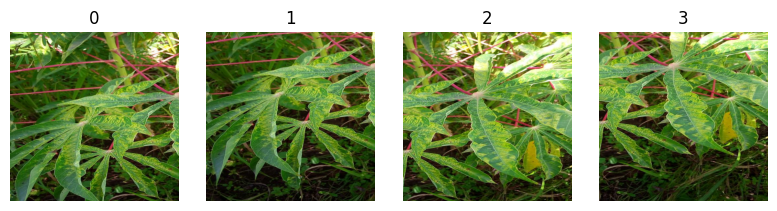

In [15]:
def scan_over_image(img_path, crop_size=512):
    """
    Extract 512x512 images covering the whole original image
    with some overlap between images
    """
    img = Image.open(img_path).convert("RGB")
    img = np.array(img)
    h, w = img.shape[0], img.shape[1]

    # Ensure crop_size isn't larger than image dims (rare but safe)
    crop_size = min(crop_size, h, w)
    x_img_origins = [0, w - crop_size] if (w - crop_size) > 0 else [0]
    y_img_origins = [0, h - crop_size] if (h - crop_size) > 0 else [0]

    img_list = []
    for x0 in x_img_origins:
        for y0 in y_img_origins:
            img_list.append(img[y0 : y0 + crop_size, x0 : x0 + crop_size, :])

    return np.array(img_list)


def display_samples(img_path):
    img_list = scan_over_image(img_path, crop_size=image_size)
    sample_number = len(img_list)
    fig = plt.figure(figsize=(8, max(2, sample_number)))
    for i in range(sample_number):
        ax = fig.add_subplot(2, 4, i + 1)
        ax.imshow(img_list[i])
        ax.set_title(str(i))
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# Optional visualization; keep but make it non-failing
try:
    display_samples(
        "../input/cassava-leaf-disease-classification/train_images/3412658650.jpg"
    )
except Exception as e:
    print("Display skipped:", e)

test_time_augmentation_layers = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomZoom(height_factor=(-0.2, 0.0), width_factor=(-0.2, 0.0)),
        layers.RandomContrast(0.2),
    ],
    name="tta_augmentation",
)




In [16]:
# Bugfix: apply same resize/rescale/preprocess pipeline at inference as training.
def _prepare_local_batch(local_image_batch_uint8):
    x = tf.cast(local_image_batch_uint8, tf.float32)
    x = tf.image.resize(
        x, [image_size, image_size], method=tf.image.ResizeMethod.BILINEAR
    )
    x = x / 255.0
    x = preprocess(x)
    return x


def predict_and_vote(image_filename, folder, TTA_runs=4):
    """
    Run the model over 4 local areas of the given image,
    before making a decision depending on the most predicted disease.
    """
    localised_predictions = []
    local_image_list = scan_over_image(
        os.path.join(folder, image_filename), crop_size=image_size
    )

    for local_image in local_image_list:
        # Duplicate for TTA
        duplicated_local_image = tf.convert_to_tensor(
            np.stack([local_image] * TTA_runs, axis=0)
        )
        augmented_images = test_time_augmentation_layers(
            duplicated_local_image, training=True
        )
        augmented_images = _prepare_local_batch(augmented_images)

        preds = model.predict(augmented_images, verbose=0)
        localised_predictions.append(np.sum(preds, axis=0))

    global_predictions = np.sum(np.array(localised_predictions), axis=0)
    final_prediction = int(np.argmax(global_predictions))
    return final_prediction


def run_predictions_over_image_list(image_list, folder):
    predictions = []
    with tqdm(total=len(image_list)) as pbar:
        for image_filename in image_list:
            predictions.append(predict_and_vote(image_filename, folder))
            pbar.update(1)
    return predictions




In [17]:
test_folder = "../input/cassava-leaf-disease-classification/test_images/"

# Bugfix: ensure correct ordering/ids using sample_submission as source of truth.
sample_sub = pd.read_csv(
    "../input/cassava-leaf-disease-classification/sample_submission.csv"
)
image_ids = sample_sub["image_id"].tolist()

submission_df = pd.DataFrame({"image_id": image_ids, "label": 0})
submission_df["label"] = run_predictions_over_image_list(
    submission_df["image_id"].tolist(), test_folder
)

submission_df.head()



  0%|          | 0/2676 [00:01<?, ?it/s]


NameError: name 'model' is not defined

In [18]:
# Write valid Kaggle submission
submission_df.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", submission_df.shape)
print(submission_df.dtypes)

Wrote submission.csv with shape: (2676, 2)
image_id    object
label        int64
dtype: object
